In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip "/content/drive/MyDrive/flower.zip" -d /content/

In [11]:

import tensorflow as tf
from tensorflow.keras.applications import ResNet152
from tensorflow.keras.applications.resnet import preprocess_input  # correct preprocessing
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import zipfile, os
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


In [12]:
dataset_path = "/content/flowers"

print(os.listdir(dataset_path))  # check folders

['tulip', 'sunflower', 'daisy', 'dandelion', 'rose']


In [15]:
# STEP 4 — Data generators
# FIX 1: preprocess_input is the CORRECT preprocessing for ResNet
# rescale=1./255 was WRONG — ResNet expects ImageNet mean subtraction

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print('Train batches:', len(train_data))
print('Val batches:', len(val_data))
print('Class mapping:', train_data.class_indices)

Found 3457 images belonging to 5 classes.
Found 860 images belonging to 5 classes.
Train batches: 109
Val batches: 27
Class mapping: {'daisy': 0, 'dandelion': 1, 'rose': 2, 'sunflower': 3, 'tulip': 4}


In [16]:
# STEP 5 — Build model
# FIX 2: Freeze entire base first, add custom classifier on top

base_model = ResNet152(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # freeze all base layers

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(train_data.num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'Trainable params: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}')
model.summary()

Trainable params: 525,829


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet152 (Functional)          │ (None, 7, 7, 2048)     │    58,370,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,896,773 (224.67 MB)

 Trainable params: 525,829 (2.01 MB)

 Non-trainable params: 58,370,944 (222.67 MB)

In [17]:
# STEP 6 — Callbacks
# FIX 3: EarlyStopping stops before overfitting
#         ReduceLROnPlateau lowers LR when stuck
#         ModelCheckpoint saves the best model automatically

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        '/content/best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print('Callbacks ready.')

Callbacks ready.


In [18]:
# STEP 7 — Phase 1: Train top layers only (fast, ~5-10 epochs)
print('Phase 1: Training classifier head only...')

history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=callbacks
)

Phase 1: Training classifier head only...
Epoch 1/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 568ms/step - accuracy: 0.4227 - loss: 1.5907
Epoch 1: val_accuracy improved from None to 0.82907, saving model to /content/best_model.keras

Epoch 1: finished saving model to /content/best_model.keras
109/109 ━━━━━━━━━━━━━━━━━━━━ 125s 831ms/step - accuracy: 0.5730 - loss: 1.1474 - val_accuracy: 0.8291 - val_loss: 0.4903 - learning_rate: 1.0000e-04
Epoch 2/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 518ms/step - accuracy: 0.7593 - loss: 0.6468
Epoch 2: val_accuracy improved from 0.82907 to 0.85465, saving model to /content/best_model.keras

Epoch 2: finished saving model to /content/best_model.keras
109/109 ━━━━━━━━━━━━━━━━━━━━ 67s 612ms/step - accuracy: 0.7773 - loss: 0.5995 - val_accuracy: 0.8547 - val_loss: 0.3926 - learning_rate: 1.0000e-04
Epoch 3/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.8242 - loss: 0.4905
Epoch 3: val_accuracy improved from 0.85465 to 0.87209, saving model to /content/b

In [20]:
# STEP 8 — Phase 2: Fine-tune last 30 layers (slightly slower)
print('Phase 2: Fine-tuning last 30 base layers...')

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Lower learning rate for fine-tuning to avoid destroying pretrained weights
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=callbacks
)

Phase 2: Fine-tuning last 30 base layers...
Epoch 1/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 628ms/step - accuracy: 0.9005 - loss: 0.2908
Epoch 1: val_accuracy did not improve from 0.90000
109/109 ━━━━━━━━━━━━━━━━━━━━ 132s 842ms/step - accuracy: 0.8993 - loss: 0.2944 - val_accuracy: 0.8942 - val_loss: 0.2962 - learning_rate: 1.0000e-05
Epoch 2/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.9177 - loss: 0.2448
Epoch 2: val_accuracy improved from 0.90000 to 0.90233, saving model to /content/best_model.keras

Epoch 2: finished saving model to /content/best_model.keras
109/109 ━━━━━━━━━━━━━━━━━━━━ 68s 622ms/step - accuracy: 0.9152 - loss: 0.2409 - val_accuracy: 0.9023 - val_loss: 0.2784 - learning_rate: 1.0000e-05
Epoch 3/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.9242 - loss: 0.2323
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 3: val_accuracy did not improve from 0.90233
109/109 ━━━━━━━━━━━━━━━━━━━━ 63s 576ms/step - accuracy: 0

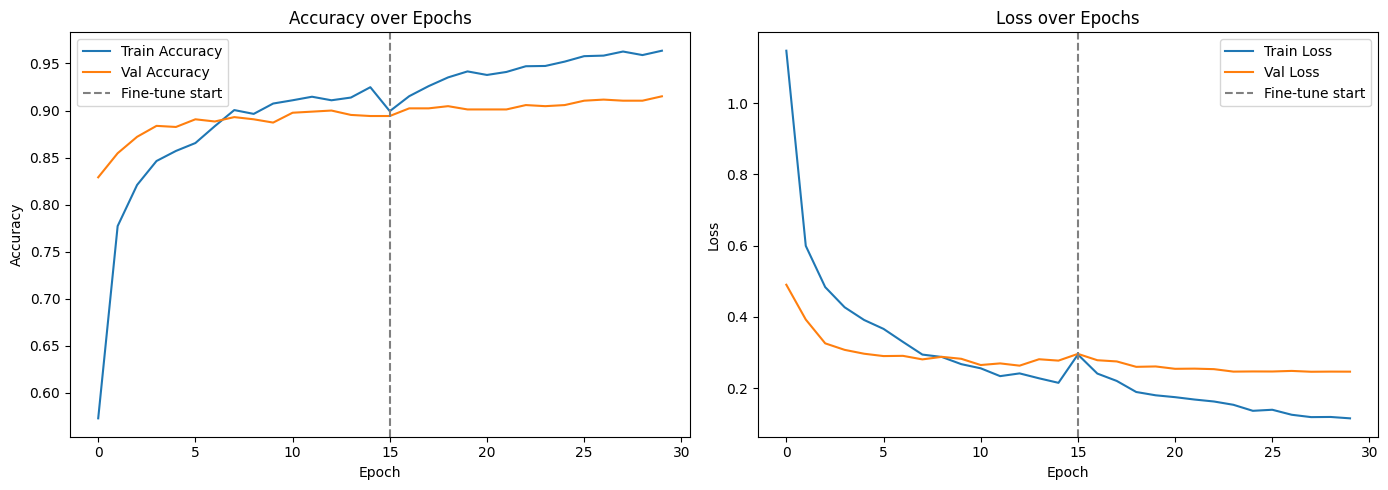

In [21]:
# STEP 9 — Plot training curves
acc  = history1.history['accuracy']     + history2.history['accuracy']
vacc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss']         + history2.history['loss']
vloss= history1.history['val_loss']     + history2.history['val_loss']
split = len(history1.history['accuracy'])

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(acc,  label='Train Accuracy')
plt.plot(vacc, label='Val Accuracy')
plt.axvline(x=split, color='gray', linestyle='--', label='Fine-tune start')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss,  label='Train Loss')
plt.plot(vloss, label='Val Loss')
plt.axvline(x=split, color='gray', linestyle='--', label='Fine-tune start')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [22]:
# STEP 10 — Evaluate on full validation set
loss, acc = model.evaluate(val_data, verbose=1)
print(f'\nFinal Validation Accuracy: {acc*100:.2f}%')
print(f'Final Validation Loss: {loss:.4f}')

27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 257ms/step - accuracy: 0.9151 - loss: 0.2463

Final Validation Accuracy: 91.51%
Final Validation Loss: 0.2463


Class names: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Found 860 images belonging to 5 classes.


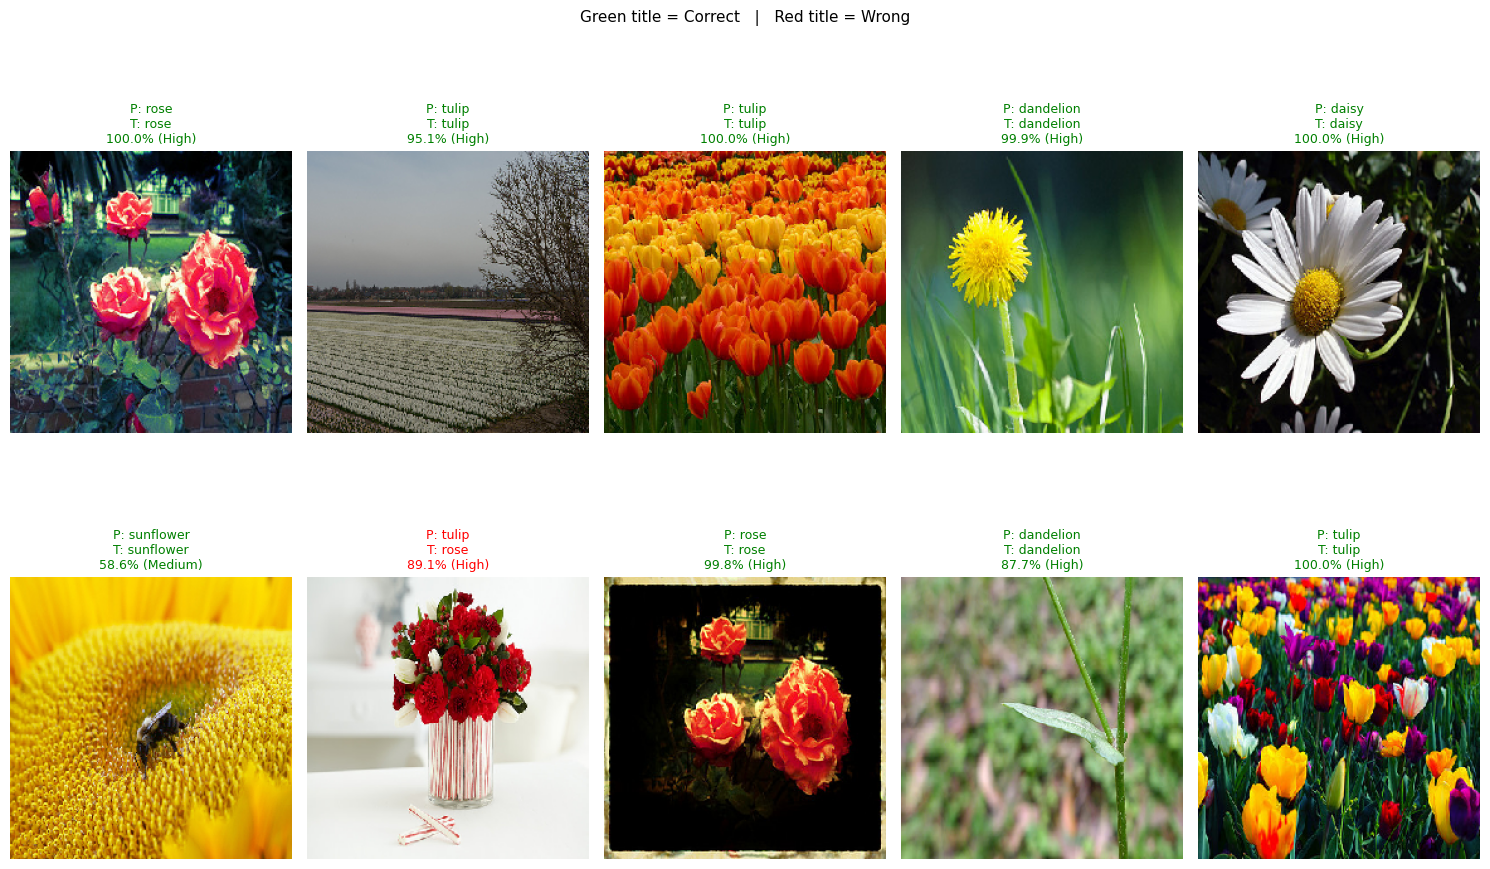

In [23]:
# STEP 11 — Predict and display (CORRECT — no colour distortion)
# FIX 4: Use a SEPARATE display generator WITHOUT preprocessing
#         Preprocess only for model input, display raw image

class_names = list(train_data.class_indices.keys())
print('Class names:', class_names)

# Raw images for display (no preprocessing)
display_datagen = ImageDataGenerator(validation_split=0.2)
display_data = display_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

raw_images, labels = next(display_data)
plt.figure(figsize=(15, 10))
for i in range(10):
    raw_img = raw_images[i]

    # Preprocess only for model — not for display
    img_for_model = preprocess_input(raw_img.copy())
    pred = model.predict(np.expand_dims(img_for_model, axis=0), verbose=0)

    predicted_class = class_names[np.argmax(pred)]
    true_class      = class_names[np.argmax(labels[i])]
    confidence      = np.max(pred) * 100

    if confidence >= 80:
        level = 'High'
    elif confidence >= 50:
        level = 'Medium'
    else:
        level = 'Low'

    correct = predicted_class == true_class
    plt.subplot(2, 5, i + 1)
    plt.imshow(raw_img.astype('uint8'))  # show normal colours
    plt.title(
        f'P: {predicted_class}\nT: {true_class}\n{confidence:.1f}% ({level})',
        color='green' if correct else 'red',
        fontsize=9
    )
    plt.axis('off')
plt.suptitle('Green title = Correct   |   Red title = Wrong', fontsize=11)
plt.tight_layout()
plt.show()

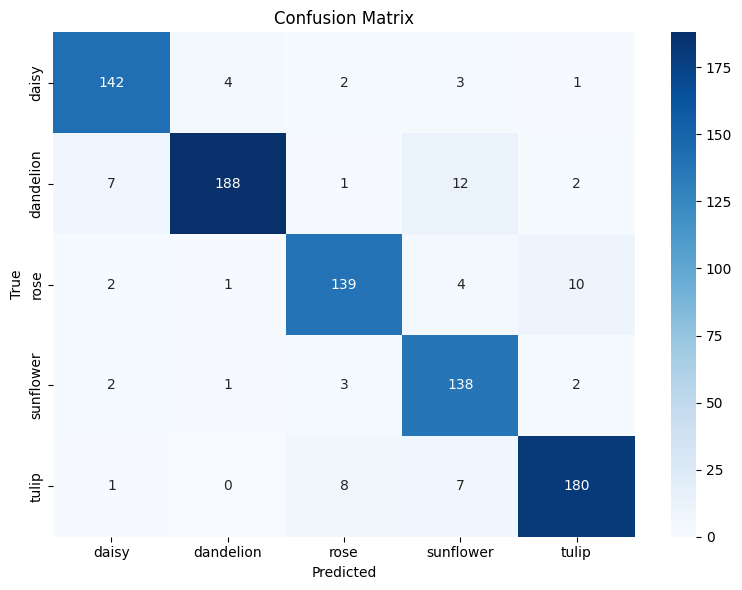


Classification Report:
              precision    recall  f1-score   support

       daisy       0.92      0.93      0.93       152
   dandelion       0.97      0.90      0.93       210
        rose       0.91      0.89      0.90       156
   sunflower       0.84      0.95      0.89       146
       tulip       0.92      0.92      0.92       196

    accuracy                           0.92       860
   macro avg       0.91      0.92      0.91       860
weighted avg       0.92      0.92      0.92       860



In [24]:
# STEP 12 — Confusion matrix + classification report
val_data.reset()
y_true, y_pred = [], []

for _ in range(len(val_data)):
    imgs, lbls = next(val_data)
    preds = model.predict(imgs, verbose=0)
    y_true.extend(np.argmax(lbls,  axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=class_names))